<a href="https://colab.research.google.com/github/batrataj/NEXUS-SEC/blob/main/notebooks/5_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
import pandas as pd

url = "https://raw.githubusercontent.com/batrataj/NEXUS-SEC/main/data/clean_network_data.xlsx"

df = pd.read_excel(url)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,BENIGN


In [15]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       199

    accuracy                           1.00       199
   macro avg       1.00      1.00      1.00       199
weighted avg       1.00      1.00      1.00       199



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


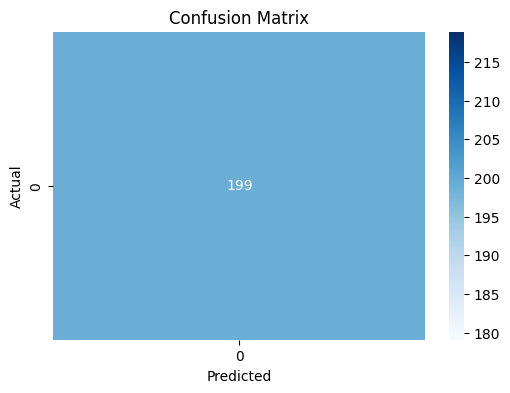

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix visualizes the performance of the classification model by comparing the predicted labels with the actual labels.

The matrix helps evaluate how accurately the model classified the data by showing correct and incorrect predictions.

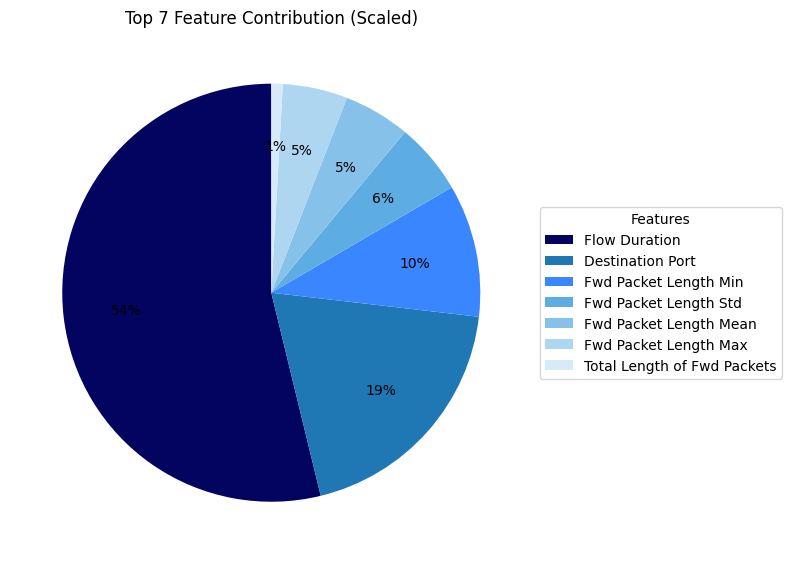

In [31]:
from sklearn.preprocessing import MinMaxScaler

numeric_df = df.select_dtypes(include=['number']).drop(columns=['Label'], errors='ignore')

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_df)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)

top_means = scaled_df.mean().sort_values(ascending=False).head(7)

plt.figure(figsize=(8,8))

colors = ["#030460","#1f77b4","#3a86ff","#5dade2","#85c1e9","#aed6f1","#d6eaf8"]

wedges, texts, autotexts = plt.pie(
    top_means.values,
    autopct='%1.0f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.7
)

plt.legend(
    wedges,
    top_means.index,
    title="Features",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Top 7 Feature Contribution (Scaled)")

plt.tight_layout()

plt.show()

This pie chart illustrates the relative contribution of the top network traffic features after scaling the data.

Each section of the chart represents the proportion of a feature's influence within the dataset. Larger portions indicate features that contribute more strongly to the overall behavior of the network traffic data.